<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# ARIMA & SARIMA Lab

---


## Learning Objectives

### Core
- Test a time series for stationarity and determine the order of differencing (d)
- Use ACF/PACF plots to reason about AR and MA terms
- Fit an ARIMA model, forecast, and evaluate it
- Detect seasonality in a series and fit a SARIMA model
- Compare ARIMA vs. SARIMA performance on the same data and explain why one wins

### Target
- Use `auto_arima` to search for (p,d,q) and seasonal (P,D,Q,m) orders
- Produce forecasts with confidence intervals


## Scenario

You are a data scientist and were given the monthly airline passenger counts. Your manager wants a short-term forecast, and wants to know whether a simple ARIMA model is good enough or whether the extra complexity of SARIMA is worth it.

You will build both models on the same data and test which model is better.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=4)
sns.set(font_scale=1.5)
plt.style.use('fivethirtyeight')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima


<div class="alert alert-info"><strong>What is the below function?:</strong> Function for running the augmented Dickey-Fuller test (adfuller).</div>

In [3]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


<div class="alert alert-info"><strong>What is the below function?:</strong> plot ACF and PACF beside each other.</div>

In [4]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax


## 1. Load and inspect the data

This is historical monthly airline passenger counts (in thousands).

In [5]:
# 1a. Load the dataset, parsing the 'month' column as dates
df = pd.read_csv('airline_passengers.csv')
df['month'] = pd.to_datetime(df['month'])

In [6]:
# 1b. Set 'month' as an Index and set the frequency to Monthly-Start (use resamling).
df.set_index('month', inplace=True)
df = df.asfreq('MS')

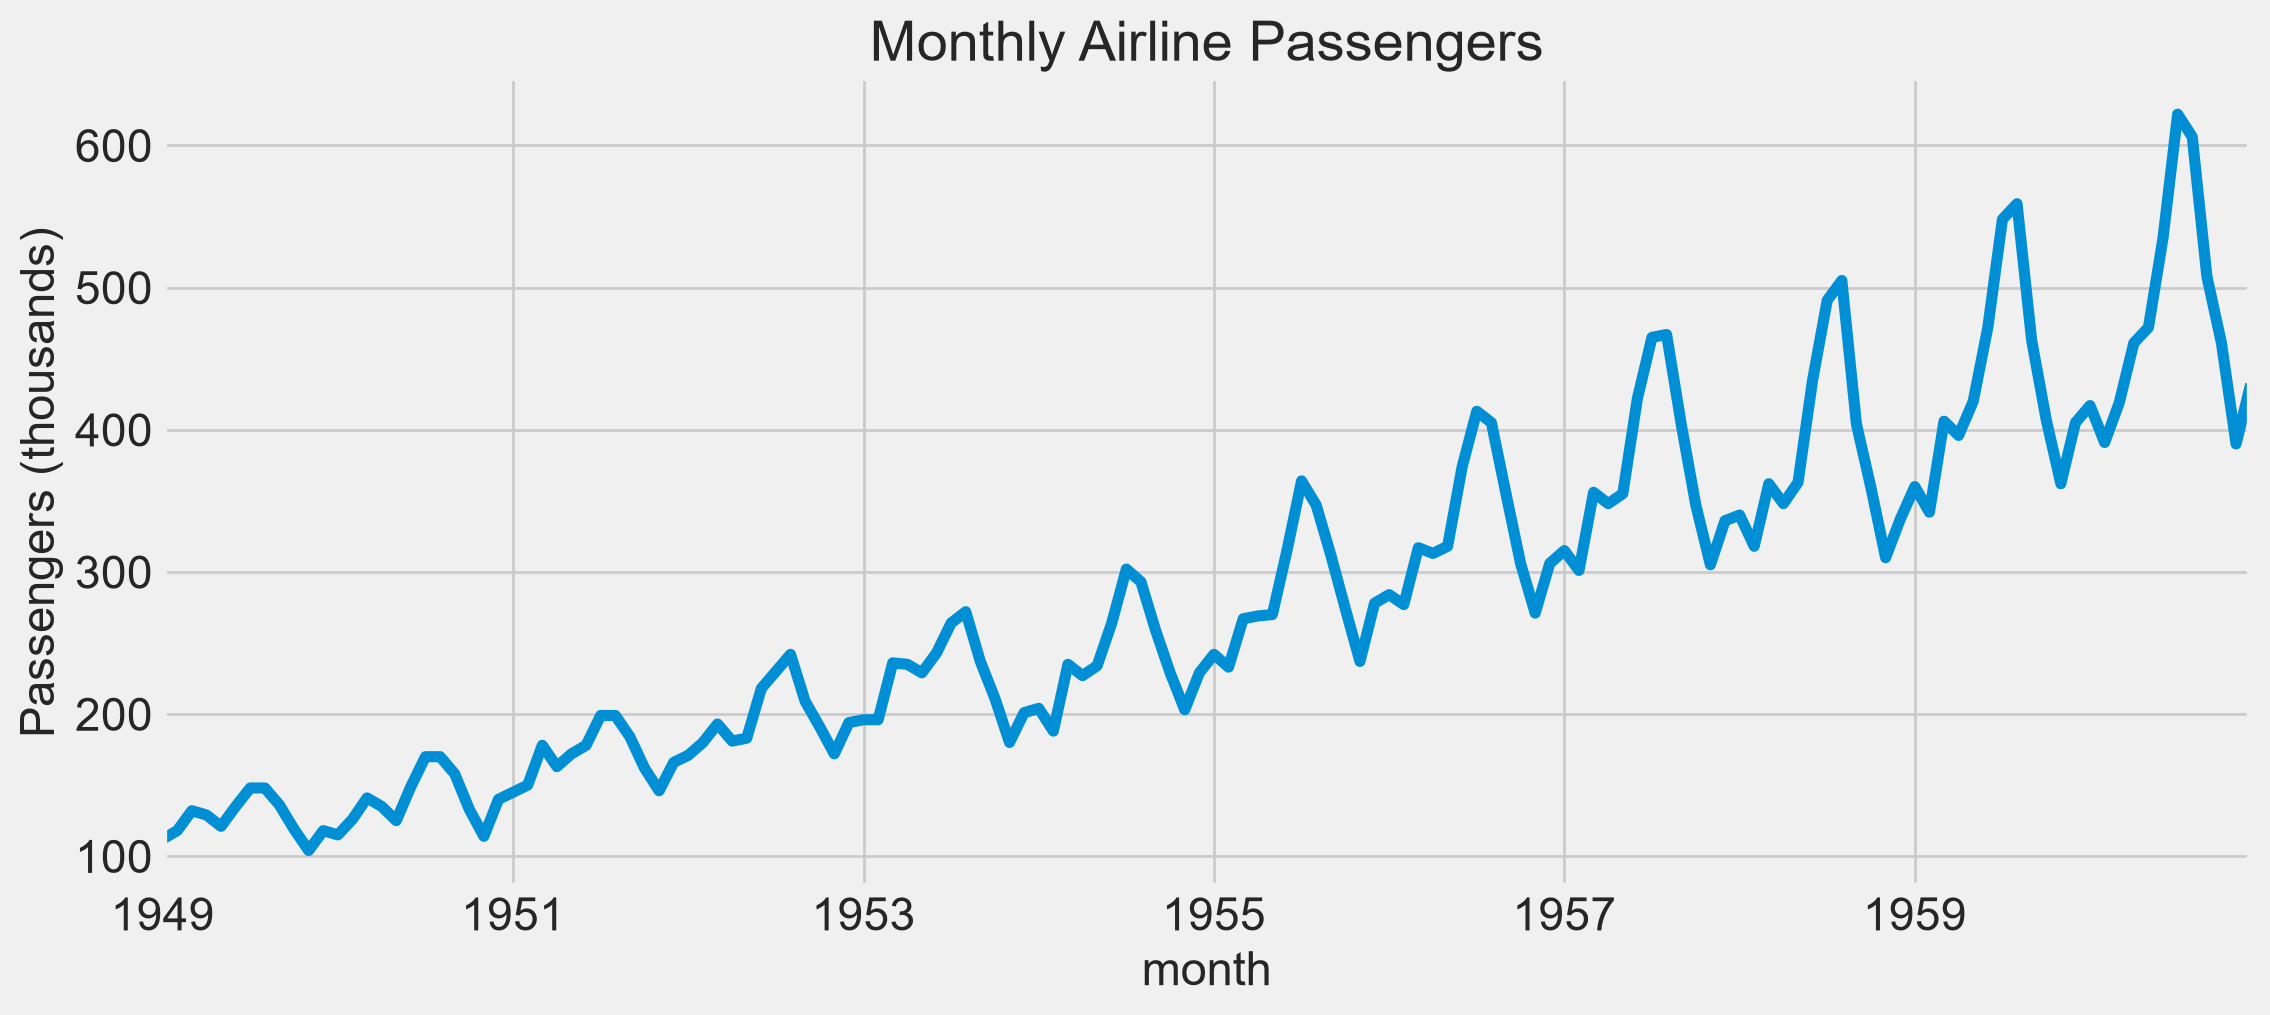

In [7]:
# 1c. Plot the full series and look at shape.
df['thousands_of_passengers'].plot(figsize=(12,5), title='Monthly Airline Passengers')
plt.ylabel('Passengers (thousands)')
plt.show()

---
# Part A - ARIMA

We'll start simple: treat this as a general time series and build a non-seasonal ARIMA model. Follow the same workflow: 

> **Stationarity -> Differencing -> ACF/PACF -> Fit -> Evaluate**.


### A1. Check stationarity

In [8]:
# Run adf_test on the passenger series. Is it stationary?
adf_test(df['thousands_of_passengers'], title='Raw Passengers')

Augmented Dickey-Fuller Test: Raw Passengers
ADF test statistic        0.815369
p-value                   0.991880
# lags used              13.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### A2. Difference until stationary

If the series isn't stationary, difference it (`.diff()`) and re-run the ADF test. Keep track of how many differences it took - that's your `d`.

In [9]:
# Difference once and re-test
adf_test(df['thousands_of_passengers'].diff(), title='1st Difference')

Augmented Dickey-Fuller Test: 1st Difference
ADF test statistic       -2.829267
p-value                   0.054213
# lags used              12.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [10]:
# If needed, difference a second time and re-test
adf_test(df['thousands_of_passengers'].diff().diff(), title='2nd Difference')

Augmented Dickey-Fuller Test: 2nd Difference
ADF test statistic     -1.638423e+01
p-value                 2.732892e-29
# lags used             1.100000e+01
# observations          1.300000e+02
critical value (1%)    -3.481682e+00
critical value (5%)    -2.884042e+00
critical value (10%)   -2.578770e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


**Write down your `d` value here:**

`d = 2`

### A3. ACF / PACF on the differenced series

Use `autocorr_plots()` on your *stationary* (differenced) series.

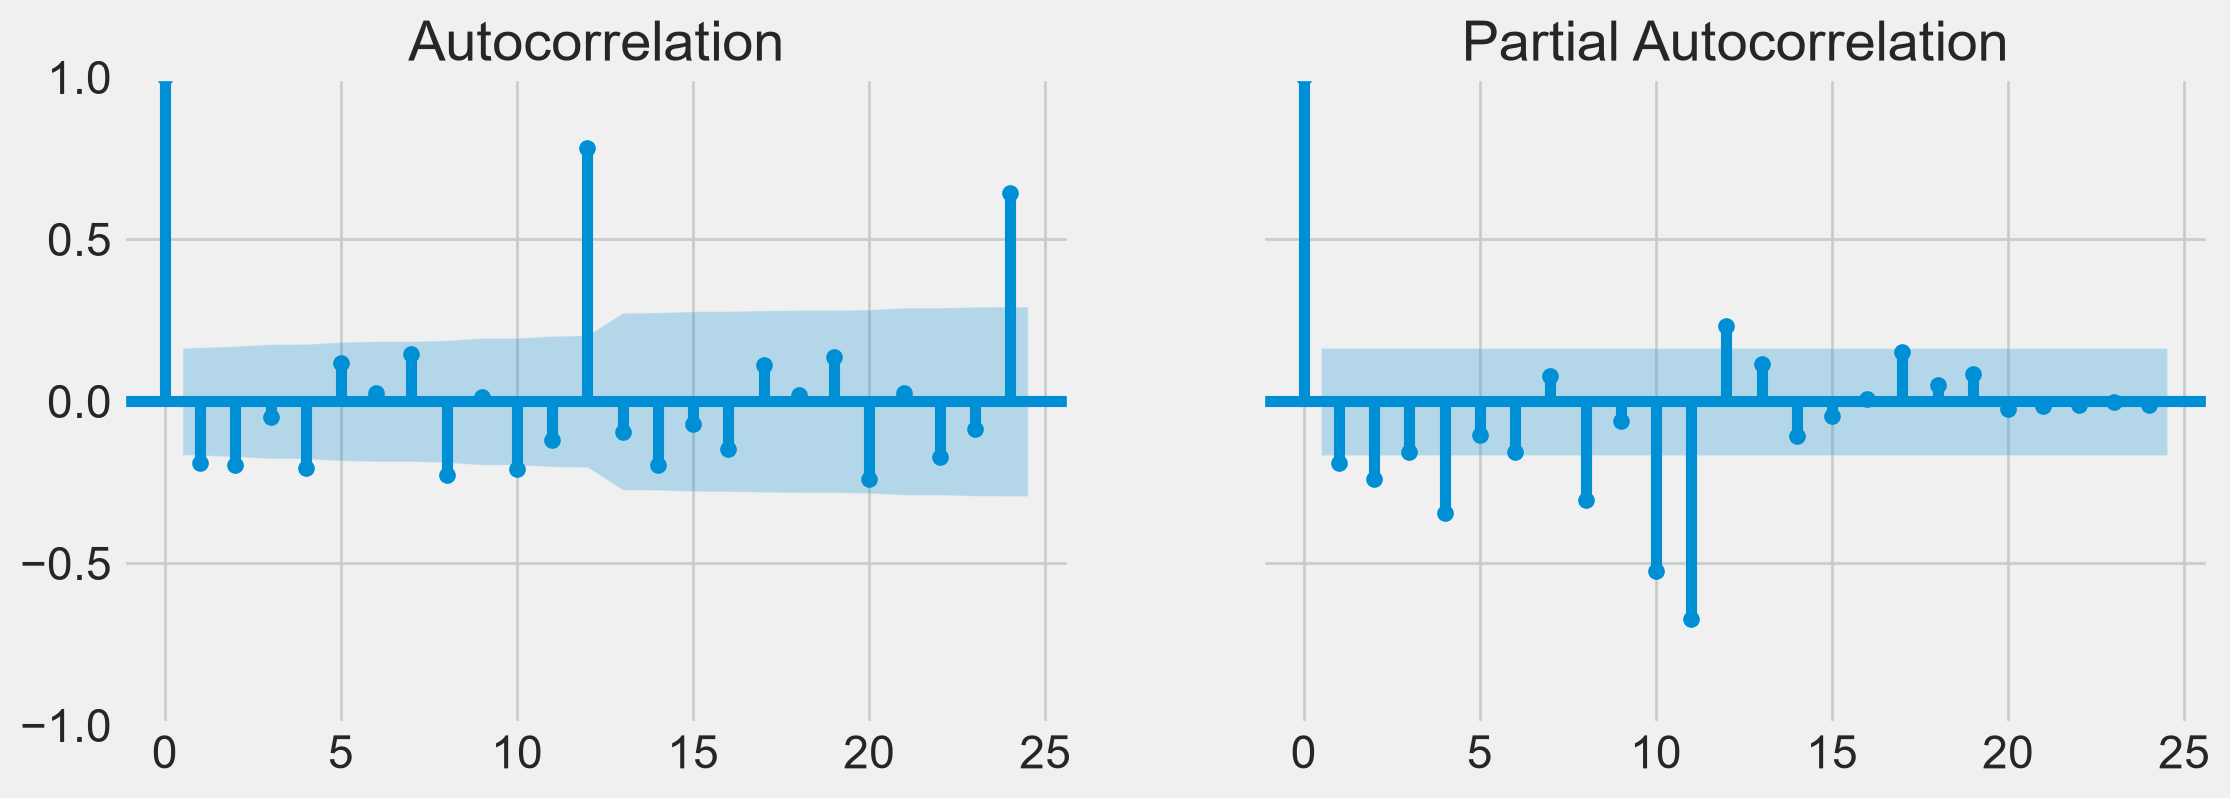

In [11]:
# Plot ACF and PACF on the differenced series, lags=24
autocorr_plots(df['thousands_of_passengers'].diff().diff().dropna(), lags=24)
plt.show()

**Based on the plots above, what would you guess for `p` and `q`?**

- p (AR terms): `1`
- q (MA terms): `1`

### A4. Confirm with auto_arima

Now check your manual guess against `auto_arima`. Keep `seasonal=False` as we are not modeling seasonality in Part A.

In [12]:
# Run auto_arima with seasonal=False and print the summary
auto_fit = auto_arima(df['thousands_of_passengers'], 
                       start_p=0, start_q=0,
                       max_p=2, max_q=2,
                       m=1,                     
                       seasonal=False,          
                       d=None,                  
                       trace=True,              
                       error_action='ignore',   
                       suppress_warnings=True,  
                       )           
auto_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.12 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.08 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.46 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.09 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -685.169
Date:                Tue, 11 Aug 2026   AIC                           1378.338
Time:                        16:39:37   BIC                           1390.190
Sample:                    01-01-1949   HQIC                          1383.154
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0907      0.083     13.190      0.000       0.929       1.253
ar.L2         -0.4890      0.097     -5.046      0.000      -0.679      -0.299
ma.L1         -0.8439      0.073    -11.486      0.000      -0.988      -0.700
sigma2       844.6059    103.095      8.192      0.000     642.543    1046.669
===================================================================================
Ljung-Box (L1) (Q):                   0.94   Jarque-Bera (JB):                 2.15
Prob(Q):                              0.33   Prob(JB):                         0.34
Heteroskedasticity (H):               7.67   Skew:                             0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A5. Train, Test, and Split

Hold out the last 12 months as your test set.

In [18]:
# Split into df_train (all but last 12 rows) and df_test (last 12 rows)
df_train = df.iloc[:-12]
df_test = df.iloc[-12:]

print(df_train.shape)
print(df_test.shape)

(132, 1)
(12, 1)


### A6. Fit the ARIMA model

Use the (p,d,q) order from A4.

In [20]:
# Fit ARIMA(p,d,q) on the training set
model_arima = ARIMA(df_train['thousands_of_passengers'], order=(2,1,1))
results_arima = model_arima.fit()
print(results_arima.summary())

                                  SARIMAX Results                                  
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(2, 1, 1)   Log Likelihood                -619.131
Date:                     Wed, 12 Aug 2026   AIC                           1246.262
Time:                             09:19:17   BIC                           1257.763
Sample:                         01-01-1949   HQIC                          1250.936
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0698      0.094     11.323      0.000       0.885       1.255
ar.L2         -0.4734      0.101     -4.670      0.000      -0.672      -0.275
ma.L1       

### A7. Predict on the test set

In [27]:
# Predict over the test period
start = len(df_train)
end = len(df_train) + len(df_test) - 1

predictions_arima = results_arima.predict(start=start, end=end)

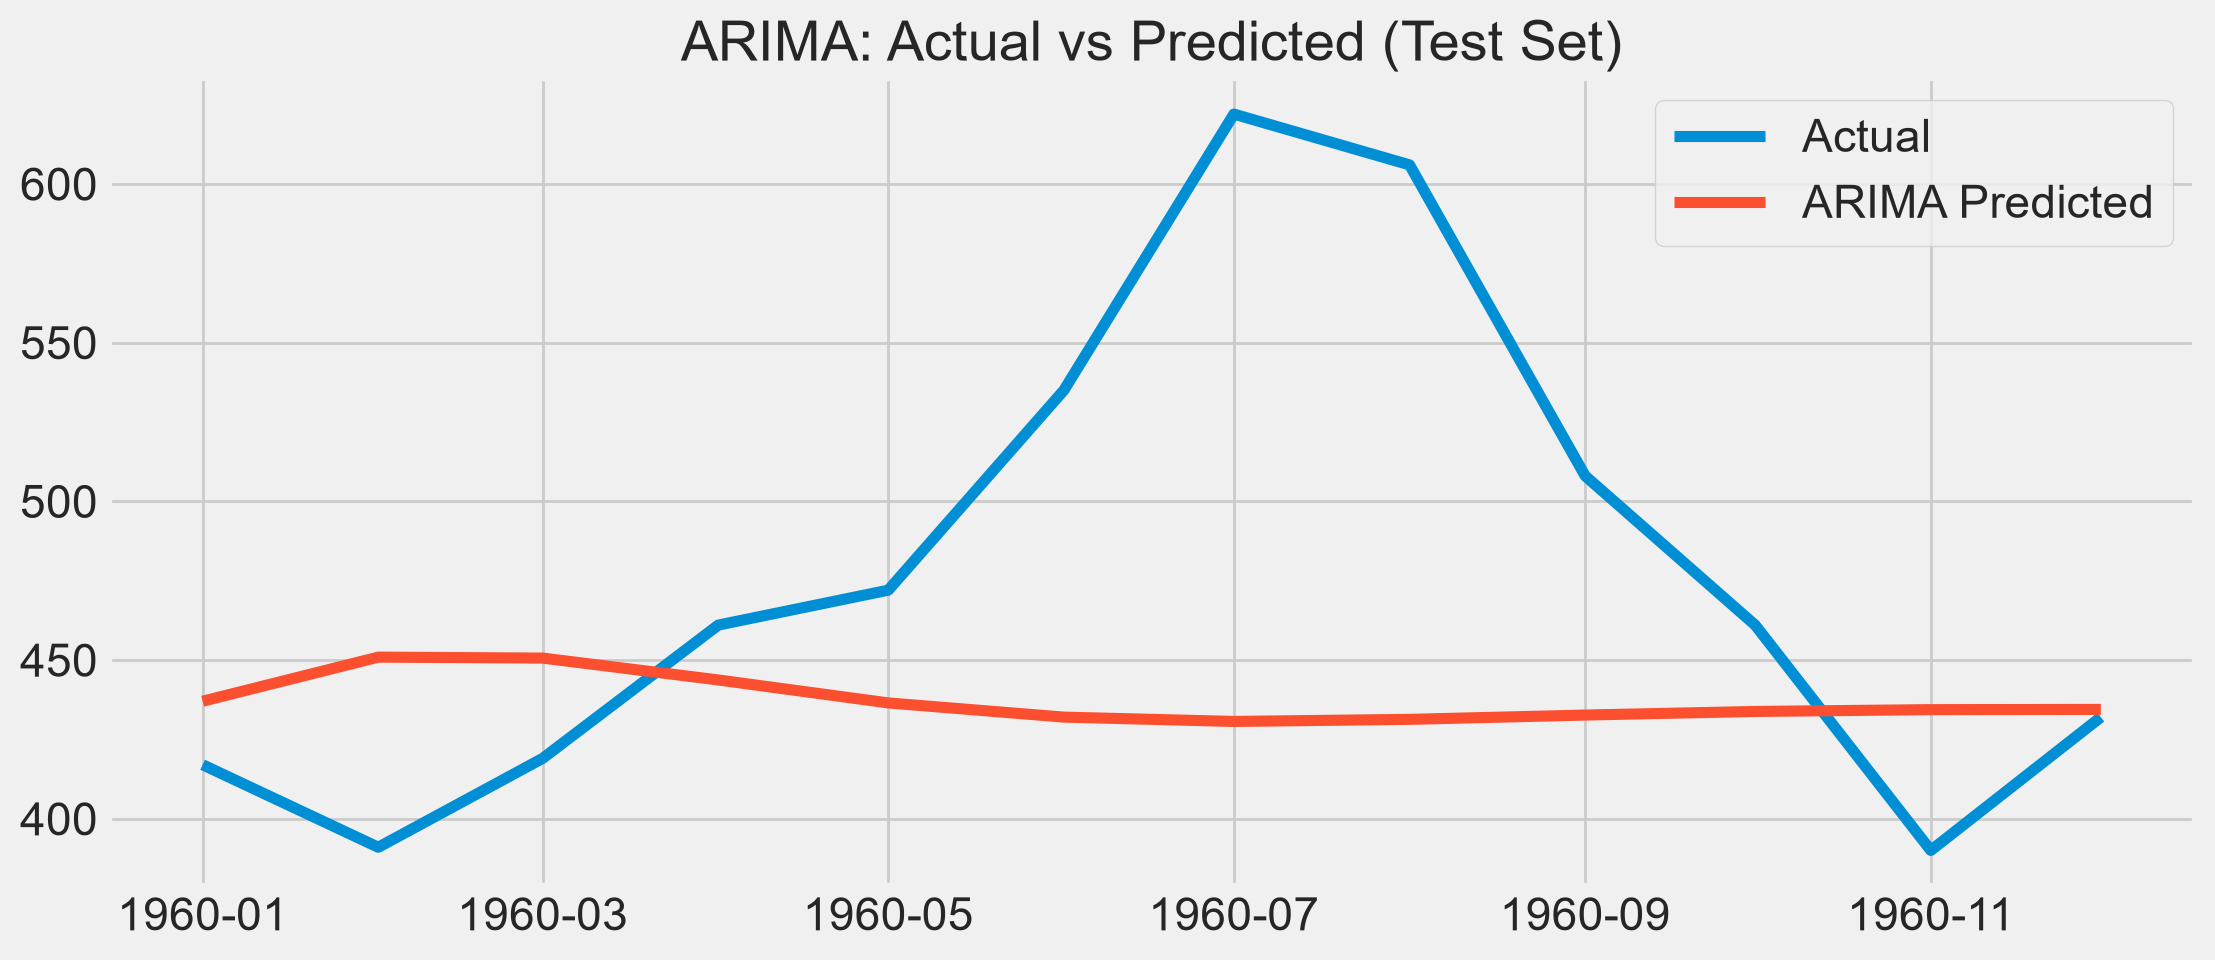

In [26]:
# Plot the test data vs predictions
plt.figure(figsize=(12,5))
plt.plot(df_test.index, df_test['thousands_of_passengers'], label='Actual')
plt.plot(df_test.index, predictions_arima, label='ARIMA Predicted')
plt.title('ARIMA: Actual vs Predicted (Test Set)')
plt.legend()
plt.show()

### A8. Evaluate

Compute RMSE for the ARIMA model. Also print the mean of the series so you have something to compare the error against.

In [28]:
# Compute RMSE
error_arima = rmse(df_test['thousands_of_passengers'], predictions_arima)
mean_value = df['thousands_of_passengers'].mean()

print(f'ARIMA RMSE: {error_arima:.2f}')
print(f'Series Mean: {mean_value:.2f}')

ARIMA RMSE: 87.88
Series Mean: 280.30


---
# Part B - SARIMA

Now let's actually look at *why* the ARIMA forecast missed. This is where we introduce seasonality.


### B1. Seasonal decomposition

Run `seasonal_decompose` on the **original** (undifferenced) series and plot it.

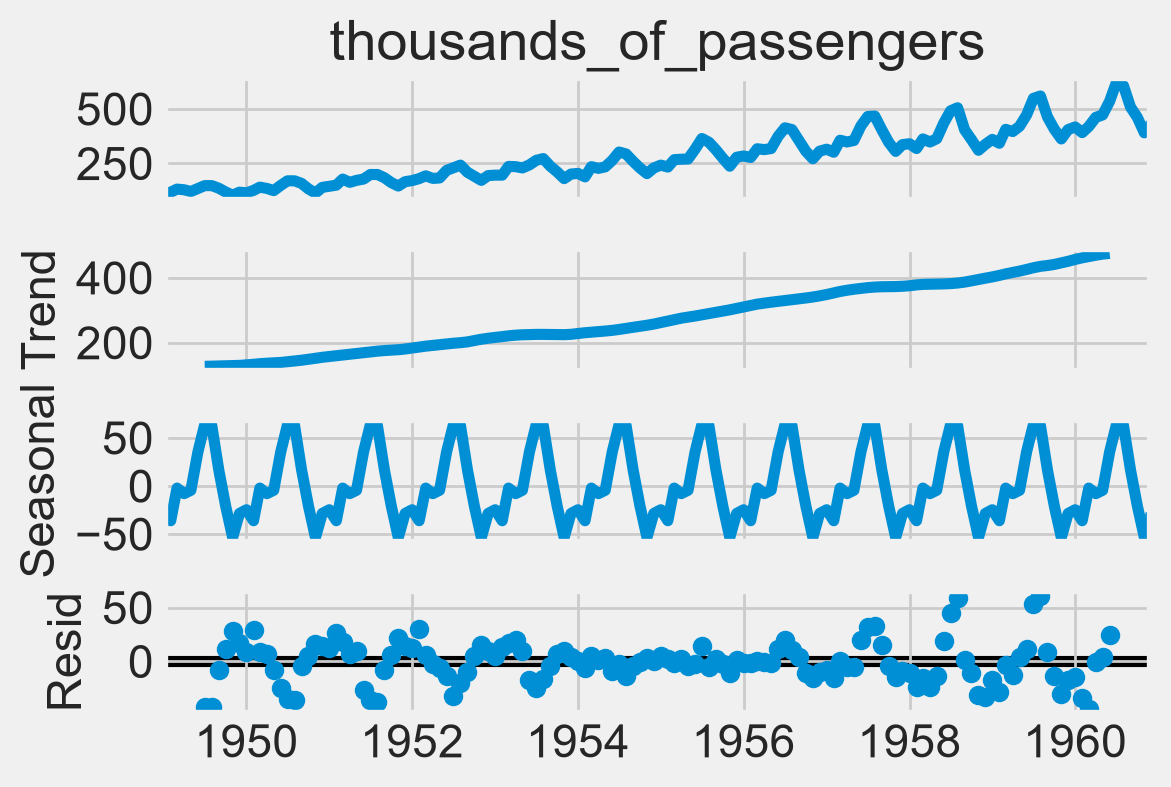

In [31]:
#YOUR CODE HERE
decomposition = seasonal_decompose(df['thousands_of_passengers'], period=12)
fig = decomposition.plot()
fig.set_size_inches(6, 4)
plt.show()

**What do you see in the seasonal component?** Is there a repeating pattern? What's the period (how many months before it repeats)?
>The seasonal component shows a clear, regularly repeating pattern of peaks and troughs that repeats every 12 months (i.e., a period of 12), consistent with the yearly seasonality we already noticed in the raw data

### B2. Search for a seasonal order with auto_arima

Run `auto_arima` again, this time with `seasonal=True` and `m=12` (12 months per cycle).

In [32]:
#YOUR CODE HERE
auto_seasonal = auto_arima(df['thousands_of_passengers'],
                            seasonal=True,
                            m=12,
                            trace=True).fit(df['thousands_of_passengers'])

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.80 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.09 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.15 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.48 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.17 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.50 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.12 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.26 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.49 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.57 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.94 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.07 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.06 sec
 ARIMA(3,1,1)(0,1,0

**Write down the order and seasonal_order suggested:**

- order (p,d,q) = (2,1,1)
- seasonal_order (P,D,Q,m) = (0,1,0,12)

### B3. Fit the SARIMA model

Use `SARIMAX` with both `order` and `seasonal_order`, fit on `df_train`.

In [33]:
#YOUR CODE HERE
model_sarima = SARIMAX(df_train['thousands_of_passengers'],
                        order=(2,1,1),
                        seasonal_order=(0,1,0,12))
results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:             thousands_of_passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -447.483
Date:                             Wed, 12 Aug 2026   AIC                            902.967
Time:                                     09:32:21   BIC                            914.083
Sample:                                 01-01-1949   HQIC                           907.481
                                      - 12-01-1959                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5253      0.929     -0.566      0.572      -2.345       1.295
ar.L2          0.0110      

C:\Users\DELL\GA_DSB\ga_dsb_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\DELL\GA_DSB\ga_dsb_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


### B4. Predict on the test set, with confidence intervals

This time, also pull the confidence interval so you can plot forecast uncertainty.

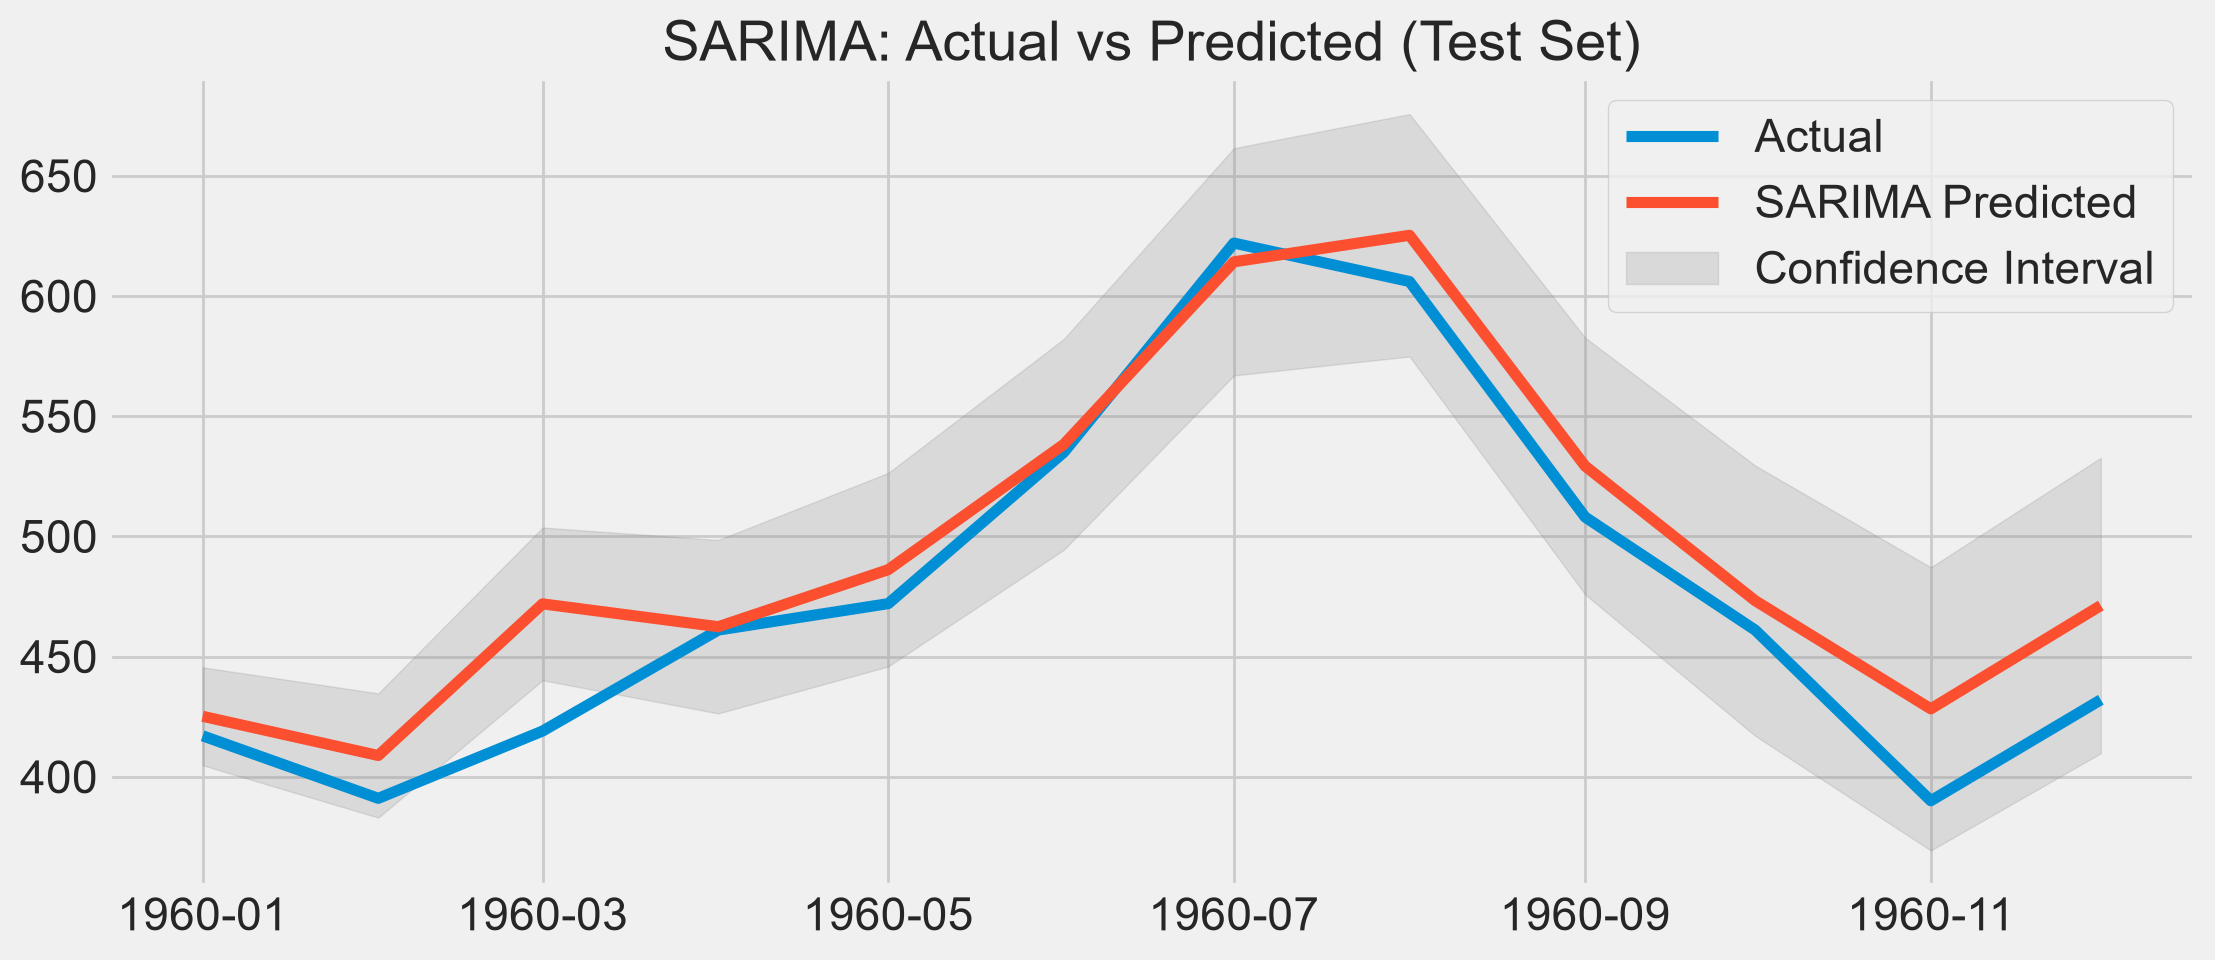

In [34]:
#YOUR CODE HERE
forecast_sarima = results_sarima.get_forecast(steps=len(df_test))
predictions_sarima = forecast_sarima.predicted_mean
conf_int = forecast_sarima.conf_int()

predictions_sarima.index = df_test.index
conf_int.index = df_test.index

plt.figure(figsize=(12,5))
plt.plot(df_test.index, df_test['thousands_of_passengers'], label='Actual')
plt.plot(df_test.index, predictions_sarima, label='SARIMA Predicted')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='gray', alpha=0.2, label='Confidence Interval')
plt.title('SARIMA: Actual vs Predicted (Test Set)')
plt.legend()
plt.show()

### B5. Evaluate

In [35]:
# Compute RMSE
error_sarima = rmse(df_test['thousands_of_passengers'], predictions_sarima)

print(f'ARIMA RMSE:  {error_arima:.2f}')
print(f'SARIMA RMSE: {error_sarima:.2f}')
print(f'Series Mean: {mean_value:.2f}')

ARIMA RMSE:  87.88
SARIMA RMSE: 24.87
Series Mean: 280.30


### B6. ARIMA vs. SARIMA

Plot both sets of predictions against the actual test values side by side and print both RMSEs together.

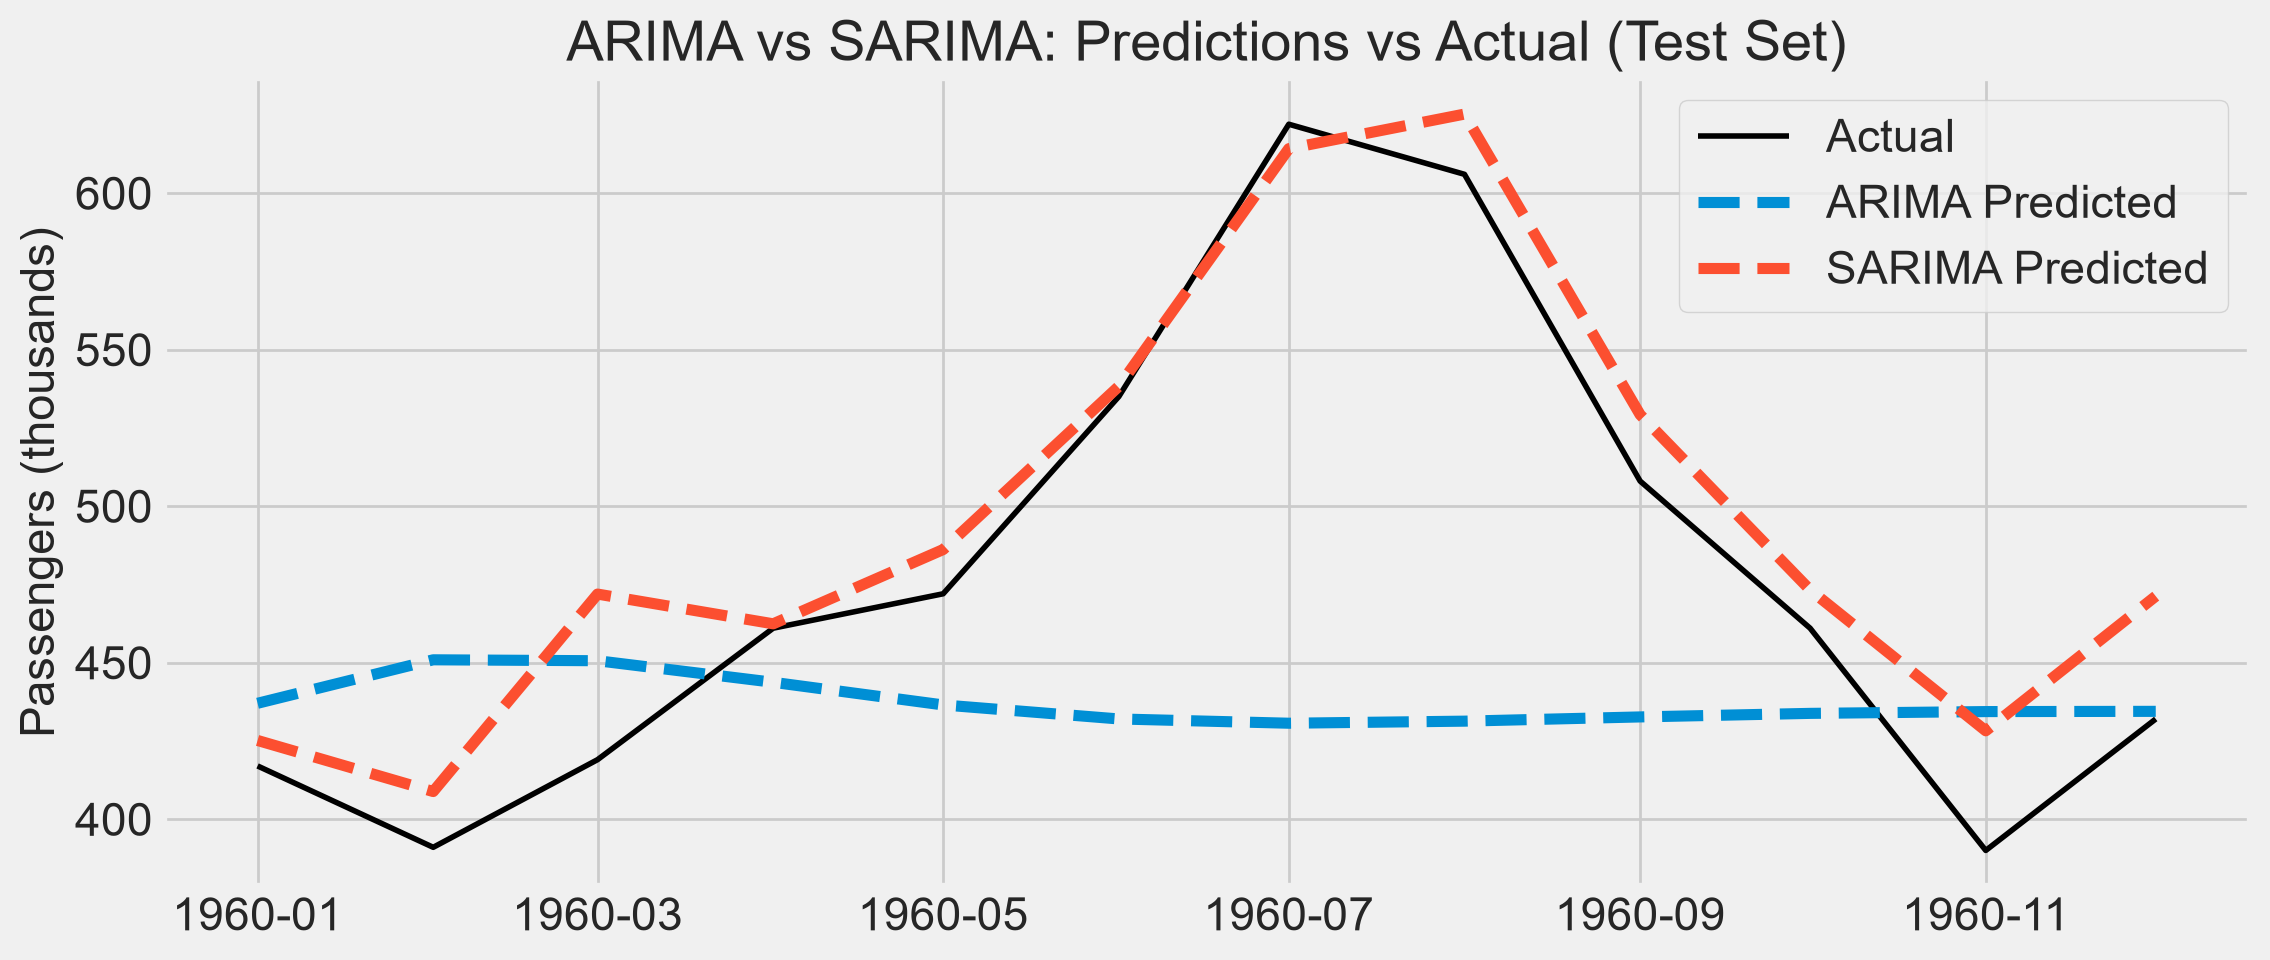

ARIMA RMSE:  87.88
SARIMA RMSE: 24.87


In [37]:
#YOUR CODE HERE
plt.figure(figsize=(12,5))
plt.plot(df_test.index, df_test['thousands_of_passengers'], label='Actual', color='black', linewidth=2)
plt.plot(df_test.index, predictions_arima, label='ARIMA Predicted', linestyle='--')
plt.plot(df_test.index, predictions_sarima, label='SARIMA Predicted', linestyle='--')
plt.title('ARIMA vs SARIMA: Predictions vs Actual (Test Set)')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.show()

print(f'ARIMA RMSE:  {error_arima:.2f}')
print(f'SARIMA RMSE: {error_sarima:.2f}')

<a id='forecast'></a>
## 2. Forecast the future

Retrain your **winning model** on the *full* dataset and forecast 12 months into the future

**Bonus**: *Plot the forecast with confidence intervals*.

In [38]:
#YOUR CODE HERE
# Retrain SARIMA on the FULL dataset
final_model = SARIMAX(df['thousands_of_passengers'],
                       order=(2,1,1),
                       seasonal_order=(0,1,0,12))
final_results = final_model.fit()

# Forecast 12 months into the future
future_forecast = final_results.get_forecast(steps=12)
future_predictions = future_forecast.predicted_mean
future_conf_int = future_forecast.conf_int()

print(future_predictions)

C:\Users\DELL\GA_DSB\ga_dsb_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\DELL\GA_DSB\ga_dsb_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


1961-01-01    445.634926
1961-02-01    420.395003
1961-03-01    449.198319
1961-04-01    491.839939
1961-05-01    503.394459
1961-06-01    566.862422
1961-07-01    654.260136
1961-08-01    638.597436
1961-09-01    540.883678
1961-10-01    494.126547
1961-11-01    423.332624
1961-12-01    465.507482
Freq: MS, Name: predicted_mean, dtype: float64


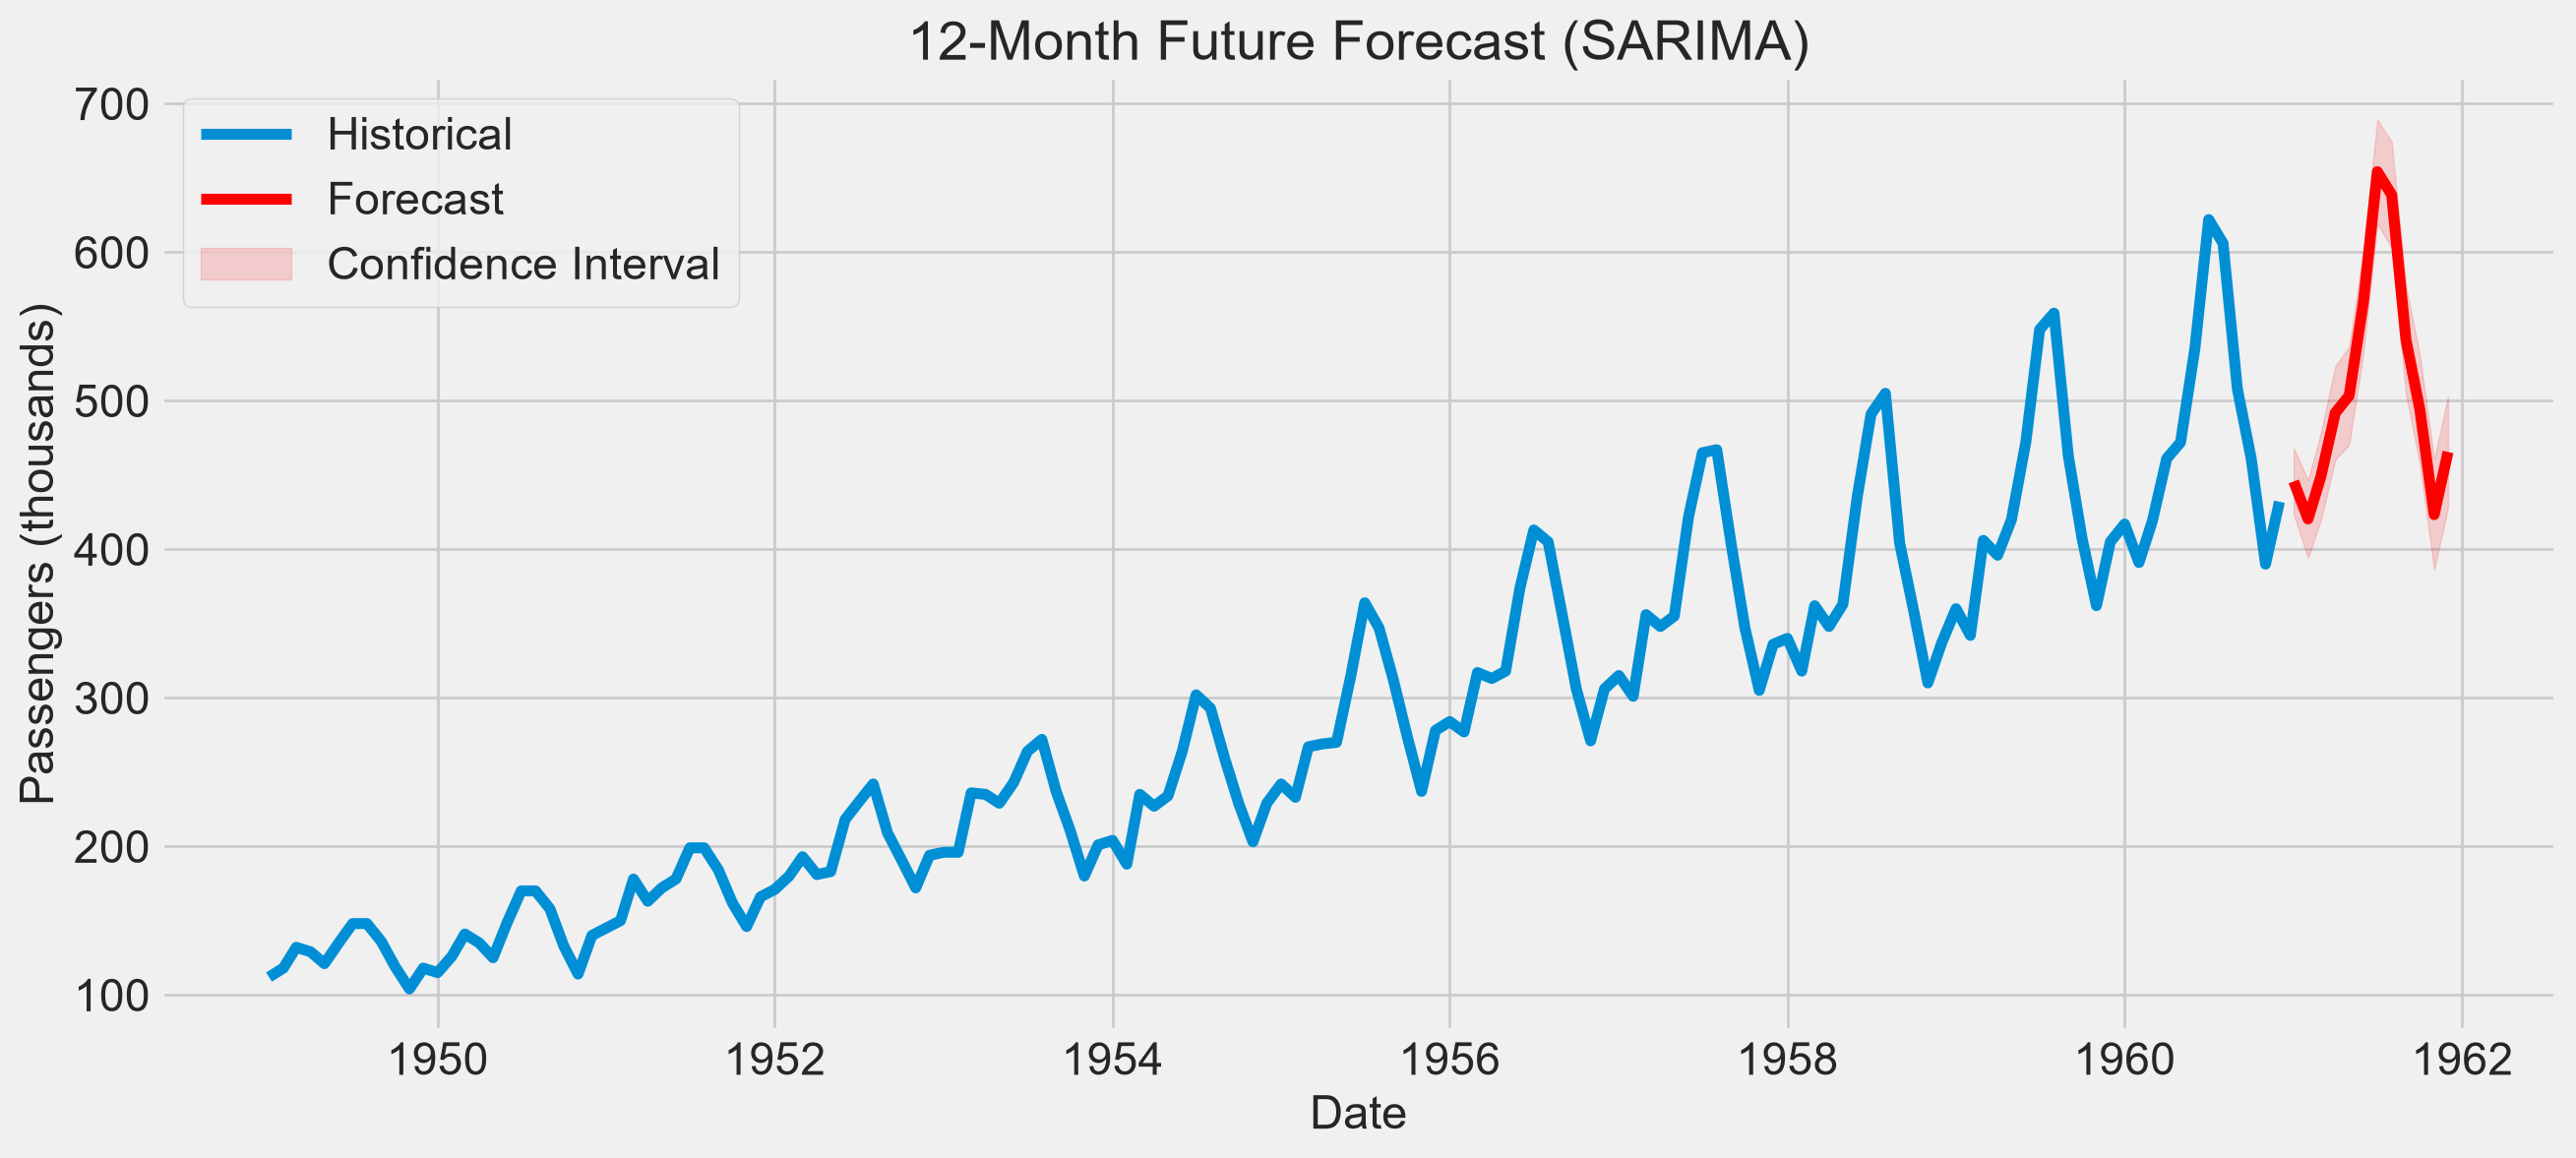

In [39]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['thousands_of_passengers'], label='Historical')
plt.plot(future_predictions.index, future_predictions, label='Forecast', color='red')
plt.fill_between(future_conf_int.index,
                  future_conf_int.iloc[:,0],
                  future_conf_int.iloc[:,1],
                  color='red', alpha=0.15, label='Confidence Interval')
plt.title('12-Month Future Forecast (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.show()

## Takeaways
- Seasonality is easy to miss if you don't plot/decompose the data, hence, always look before you model.
- SARIMA isn't automatically the right call; it's justified when the seasonal component is real and the added parameters actually reduce error on held-out data.
- Always evaluate on a proper time-ordered train,test, and split.


## Additional Resources
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima auto_arima documentation](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)
- [Forecasting: Principles and Practice - Seasonal ARIMA](https://otexts.com/fpp2/seasonal-arima.html)
